# Disease association

**Which genera differ between cases and controls — and which of those differences survive being
computed two different ways?** The technical-variance step already showed that a sample's
originating study is the single largest axis of between-sample variation (marginal R² ≈ 0.39–0.43,
vs case/control status ≈ 0.01), and that a linear model recovers the study from composition at
~0.76 accuracy against a 0.04 baseline. So a pooled case/control signal has to be read against how
easily a model can latch onto the lab instead. The logic lives in `src/differential.py`; this
notebook runs it once end to end and writes `reports/differential_{per_project,meta,pooled}.csv`,
`reports/concordance.csv`, `reports/classifier_cv.csv`, `reports/differential_report.md` and the
`reports/figures/phase5_*.png` figures.

Five steps:

1. **Within-project differential abundance.** Per project, per disease category, an OLS
   case/control contrast on each within-project prevalence-filtered taxon (covariate-adjusted for
   `age_years` / `sex` where coverage allows), with a Wilcoxon rank-sum carried alongside.
   BH-FDR within each project.
2. **Random-effects meta-analysis.** DerSimonian-Laird pooling of the per-project effect sizes.
   Never pools raw samples across labs.
3. **Naive pooled + batch correction.** The same samples pooled across projects and tested,
   corrected for study two ways: parametric ComBat on the CLR matrix + OLS, and a project
   random-intercept mixed model.
4. **Concordance (the centrepiece).** Meta-analysis vs pooled test: overlap at FDR, effect-size
   rank correlation, sign agreement, and a scatter. Every taxon classified *replicated* /
   *pooling-only* / *within-only*.
5. **Batch-leakage quantification.** A disease classifier under leave-one-project-out vs random
   stratified k-fold CV. The AUC gap is how much apparent accuracy is study recognition.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import differential as dfa

REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"
INTERIM = ROOT / "data" / "interim"

with open(ROOT / "config" / "params.yaml") as f:
    params = yaml.safe_load(f)
SEED = params["seed"]
dcfg = params["differential"]
blcfg = dcfg["batch_leakage"]

print(f"seed={SEED}  fdr_alpha={dcfg['fdr_alpha']}")
print(f"category eligibility: >= {dcfg['min_projects_per_category']} projects "
      f"(>= {dcfg['min_cases_per_project']}/{dcfg['min_controls_per_project']} each) "
      f"and >= {dcfg['min_cases_per_category']} cases total")
print(f"within-contrast prevalence filter: {dcfg['within_prevalence']:.0%}")
print(f"category_groups (collapse): {dcfg['category_groups']}")

seed=42  fdr_alpha=0.05
category eligibility: >= 2 projects (>= 10/10 each) and >= 100 cases total
within-contrast prevalence filter: 10%
category_groups (collapse): {'IBD_CD': 'IBD', 'IBD_UC': 'IBD', 'IBD': 'IBD'}


## Load the cohorts and build the per-category contrast frame

`cohort_within_project.parquet` (41 projects / 14,033 samples) is the within-study cohort. Every
case row already carries a `disease_category`; controls don't (harmonisation only categorises
cases), so each control is expanded to one contrast row per case category present in *its own*
project. The IBD subtypes (`IBD_CD` / `IBD_UC` / `IBD`) are collapsed to a single `IBD` — CD, UC
and unspecified IBD are one disease family — via `config/params.yaml` → `differential.category_groups`.

In [2]:
within_project = pd.read_parquet(PROCESSED / "cohort_within_project.parquet")
print("within_project:", within_project.shape)

frame = dfa.build_analysis_frame(within_project, category_groups=dcfg["category_groups"])
print(f"contrast frame: {len(frame):,} (sample, category) rows  "
      f"[{int((frame['y'] == dfa.CASE).sum()):,} case / {int((frame['y'] == dfa.CONTROL).sum()):,} control rows]")

cat_counts = dfa.category_counts(frame, dcfg["min_cases_per_project"], dcfg["min_controls_per_project"])
elig = dfa.eligible_categories(cat_counts, dcfg["min_projects_per_category"],
                               dcfg["min_cases_per_category"])
print("\nEligible disease categories:")
print(elig.to_string())

print("\nExcluded (non-disease buckets or too few projects/cases):")
excluded = (cat_counts.groupby("disease_category")
            .agg(projects_ok=("ok", "sum"), cases=("n_case", "sum"))
            .loc[lambda d: ~d.index.isin(elig.index)]
            .sort_values("cases", ascending=False))
print(excluded.to_string())

within_project: (14033, 92)


contrast frame: 14,176 (sample, category) rows  [5,669 case / 8,507 control rows]

Eligible disease categories:
                  n_projects  n_cases  n_controls
disease_category                                 
cancer_other               4      657         303
IBD                        4      557         151
HIV                        3      359         148
asthma                     3      248         220
NAFLD                      3      104         111
T1D                        2      100         123

Excluded (non-disease buckets or too few projects/cases):
                  projects_ok  cases
disease_category                    
other                      11   2167
PD                          1    462
healthy_only                3    318
CDI                         1    200
NEC                         1    177
ASD                         2     76
gastric_cancer              1     54
eczema                      1     53
depression                  1     43
T2D                   

## Load CLR + within-taxon presence

`abund_clr.parquet` (≥1%-prevalence taxa, CLR) supplies the values every test runs on.
`taxa_prev01.npz` (the sparse ≥1%-prevalence *counts*) supplies presence, used to
prevalence-filter *within* each small contrast — a genus common compendium-wide can be near-absent
inside one project.

In [3]:
need = set(frame.loc[frame["disease_category"].isin(elig.index), "sample"])
t0 = time.time()
clr_df, taxa = dfa.load_clr(PROCESSED / "abund_clr.parquet", need)
presence = dfa.presence_matrix(INTERIM / "taxa_prev01.npz")
print(f"CLR subset: {clr_df.shape}  ({len(taxa)} taxa)")
print(f"presence matrix: {presence.shape}  ({time.time() - t0:.0f}s)")

missing = need - set(clr_df.index)
print(f"{len(missing)} needed sample(s) absent from abund_clr.parquet "
      f"(the zero-mass CLR exclusion, if any): {sorted(missing)[:3]}")
CATS = list(elig.index)

CLR subset: (3081, 419)  (419 taxa)
presence matrix: (168464, 419)  (5s)
0 needed sample(s) absent from abund_clr.parquet (the zero-mass CLR exclusion, if any): []


## Step 1 — Within-project differential abundance

Per project carrying a category's cases: an OLS contrast `clr ~ case (+ age_years + sex)` on each
within-project prevalence-filtered taxon (`differential.within_prevalence`), giving the effect
size + SE the meta-analysis needs. `age_years` / `sex` enter only where both arms have ≥
`covariate_min_coverage` non-null (recorded per row in `covariates`). A Wilcoxon rank-sum p and
rank-biserial correlation on the raw CLR are carried alongside as the non-parametric cross-check
(ANCOM-BC / ALDEx2 via `rpy2` are not installed here — this is the pure-Python route). BH-FDR
within each project.

In [4]:
t0 = time.time()
per_project = pd.concat(
    [dfa.differential_within_project(
        clr_df, presence, frame, cat, taxa,
        within_prevalence=dcfg["within_prevalence"],
        covariate_min_coverage=dcfg["covariate_min_coverage"],
        min_cases=dcfg["min_cases_per_project"],
        min_controls=dcfg["min_controls_per_project"])
     for cat in CATS],
    ignore_index=True,
)
per_project.to_csv(REPORTS / "differential_per_project.csv", index=False)
print(f"within-project: {len(per_project):,} (project, taxon) tests across "
      f"{per_project['project'].nunique()} projects, {per_project['disease_category'].nunique()} categories "
      f"({time.time() - t0:.0f}s)")

universe = (per_project.groupby(["disease_category", "project"])
            .agg(n_taxa=("n_taxa_tested", "first"), n_case=("n_case", "first"),
                 n_control=("n_control", "first"), covariates=("covariates", "first"),
                 n_sig=("q", lambda s: int((s < dcfg["fdr_alpha"]).sum())))
            .reset_index())
print("\nMultiple-testing universe per project (taxa tested) and FDR hits:")
print(universe.to_string(index=False))

within-project: 2,947 (project, taxon) tests across 19 projects, 6 categories (12s)

Multiple-testing universe per project (taxa tested) and FDR hits:
disease_category     project  n_taxa  n_case  n_control    covariates  n_sig
             HIV   PRJEB4335     195      29         20     age_years     48
             HIV PRJNA307231     149     248         44 age_years,sex      1
             HIV PRJNA589036     206      82         84 age_years,sex     10
             IBD  PRJEB42155     169     183         18                   45
             IBD PRJNA398089     151     104         42           sex     21
             IBD PRJNA413199     180     251         70                   89
             IBD PRJNA610934     225      19         21 age_years,sex      0
           NAFLD PRJNA246121     171      53         31 age_years,sex      2
           NAFLD PRJNA382861     104      31         26                    1
           NAFLD PRJNA480711     196      20         54 age_years,sex      1
  

## Step 2 — Random-effects meta-analysis

DerSimonian-Laird: inverse-variance weights on the per-project `(effect, se)`, plus a
between-study variance component `tau²`. A taxon needs ≥ `meta_min_projects_per_taxon` project
estimates to be pooled. BH-FDR within category. **This never pools raw samples across labs**, so
batch effects can't enter the pooled estimate — it is the statistically correct multi-study
design, and the one the concordance step treats as ground truth.

In [5]:
meta = dfa.meta_analyze(per_project, min_projects_per_taxon=dcfg["meta_min_projects_per_taxon"])
meta.to_csv(REPORTS / "differential_meta.csv", index=False)

print(f"meta: {len(meta):,} pooled (category, taxon) estimates")
print(meta.groupby("disease_category")
      .agg(n_taxa=("taxon", "size"),
           n_sig=("q", lambda s: int((s < dcfg["fdr_alpha"]).sum())),
           median_I2=("I2", "median"))
      .to_string())

print(f"\nMeta-analysis hits (q < {dcfg['fdr_alpha']}):")
hits = meta[meta["q"] < dcfg["fdr_alpha"]].sort_values(["disease_category", "q"])
cols = ["disease_category", "genus", "k_projects", "pooled_effect", "ci_low", "ci_high", "I2", "q", "sign_consistency"]
print(hits[cols].round(3).to_string(index=False) if len(hits) else "  (none)")

fig = dfa.plot_meta_volcano(meta, fdr_alpha=dcfg["fdr_alpha"])
fig.savefig(FIGURES / "phase5_meta_volcano.png"); plt.close(fig)

meta: 859 pooled (category, taxon) estimates
                  n_taxa  n_sig  median_I2
disease_category                          
HIV                  177      8  50.345916
IBD                  190     81   3.166351
NAFLD                153     10   0.000000
T1D                   57      0   0.000000
asthma               119      0  12.840467
cancer_other         163      2   0.000000

Meta-analysis hits (q < 0.05):
disease_category                              genus  k_projects  pooled_effect  ci_low  ci_high     I2     q  sign_consistency
             HIV                         Romboutsia           3         -1.218  -1.734   -0.701  0.000 0.001             1.000
             HIV      Christensenellaceae R-7 group           3         -0.975  -1.435   -0.514  0.000 0.003             1.000
             HIV                     Incertae Sedis           3         -1.325  -2.023   -0.627 15.598 0.012             1.000
             HIV                            UCG-005           3        

## Step 3 — Naive pooled + batch correction

The **same** case+control samples the meta-analysis used, per category, but pooled across projects
and tested one of two ways (`differential.pooled_methods`):

- **combat_ols** — parametric ComBat (`combat_adjust`) removes each project's location/scale shift
  from the CLR matrix, *protecting* the case indicator (and any covariates), then a vectorised OLS
  contrast.
- **mixedlm** — `statsmodels` MixedLM with a project random intercept, per taxon
  (iteration-capped so a near-degenerate taxon can't loop for minutes).

Pooling the identical sample set as Step 2 means the concordance step isolates the effect of the
*analysis design* (pooled-with-correction vs meta), not a difference in which samples were used.

In [6]:
t0 = time.time()
pooled = pd.concat(
    [dfa.differential_pooled(
        clr_df, presence, frame, cat, taxa,
        methods=tuple(dcfg["pooled_methods"]),
        within_prevalence=dcfg["within_prevalence"],
        covariate_min_coverage=dcfg["covariate_min_coverage"],
        progress=False)
     for cat in CATS],
    ignore_index=True,
)
pooled.to_csv(REPORTS / "differential_pooled.csv", index=False)
print(f"pooled: {len(pooled):,} tests ({time.time() - t0:.0f}s)")

summ = (pooled.groupby(["disease_category", "method"])
        .agg(n_taxa=("taxon", "size"),
             n_sig=("q", lambda s: int((s < dcfg["fdr_alpha"]).sum())),
             converged=("converged", "mean") if "converged" in pooled.columns else ("taxon", "size"))
        .reset_index())
print(summ.to_string(index=False))
if "converged" in pooled.columns:
    n_nonconv = int((pooled["method"].eq("mixedlm") & pooled["converged"].eq(False)).sum())
    print(f"\nmixedlm: {n_nonconv} non-converged taxon fits (effect kept as NaN, excluded from concordance)")

pooled: 2,186 tests (25s)
disease_category     method  n_taxa  n_sig converged
             HIV combat_ols     189     41       NaN
             HIV    mixedlm     189     37  0.994709
             IBD combat_ols     181    116       NaN
             IBD    mixedlm     181    120       1.0
           NAFLD combat_ols     187     16       NaN
           NAFLD    mixedlm     187     37  0.994652
             T1D combat_ols     119      0       NaN
             T1D    mixedlm     119      1  0.983193
          asthma combat_ols     242      0       NaN
          asthma    mixedlm     242      0       1.0
    cancer_other combat_ols     175      3       NaN
    cancer_other    mixedlm     175      2       1.0

mixedlm: 4 non-converged taxon fits (effect kept as NaN, excluded from concordance)


## Step 4 — Concordance (the centrepiece)

Join the meta-analysis against each pooled method per `(category, taxon)` and classify:

| class | meaning |
|---|---|
| **replicated** | q < α in *both* — the confident findings |
| **pooling-only** | q < α in the pooled test only — likely a batch artifact the meta-analysis correctly resisted |
| **within-only** | q < α in the meta-analysis only — likely real but under-powered once pooled |

Plus the effect-size Spearman correlation and sign agreement per category. `combat_ols` is the
primary comparison; `mixedlm` is reported alongside.

Concordance summary (per category x pooled method):
disease_category pooled_method  n_taxa  n_tested_both  n_replicated  n_pooling_only  n_within_only  spearman_effect  sign_agreement
             HIV    combat_ols     194            172             8              33              0            0.431           0.709
             IBD    combat_ols     193            178            76              40              5            0.979           0.972
           NAFLD    combat_ols     190            150             8               8              2            0.861           0.873
             T1D    combat_ols     119             57             0               0              0            0.980           0.965
          asthma    combat_ols     248            113             0               0              0            0.927           0.894
    cancer_other    combat_ols     179            159             0               3              2           -0.758           0.151
             HIV       m

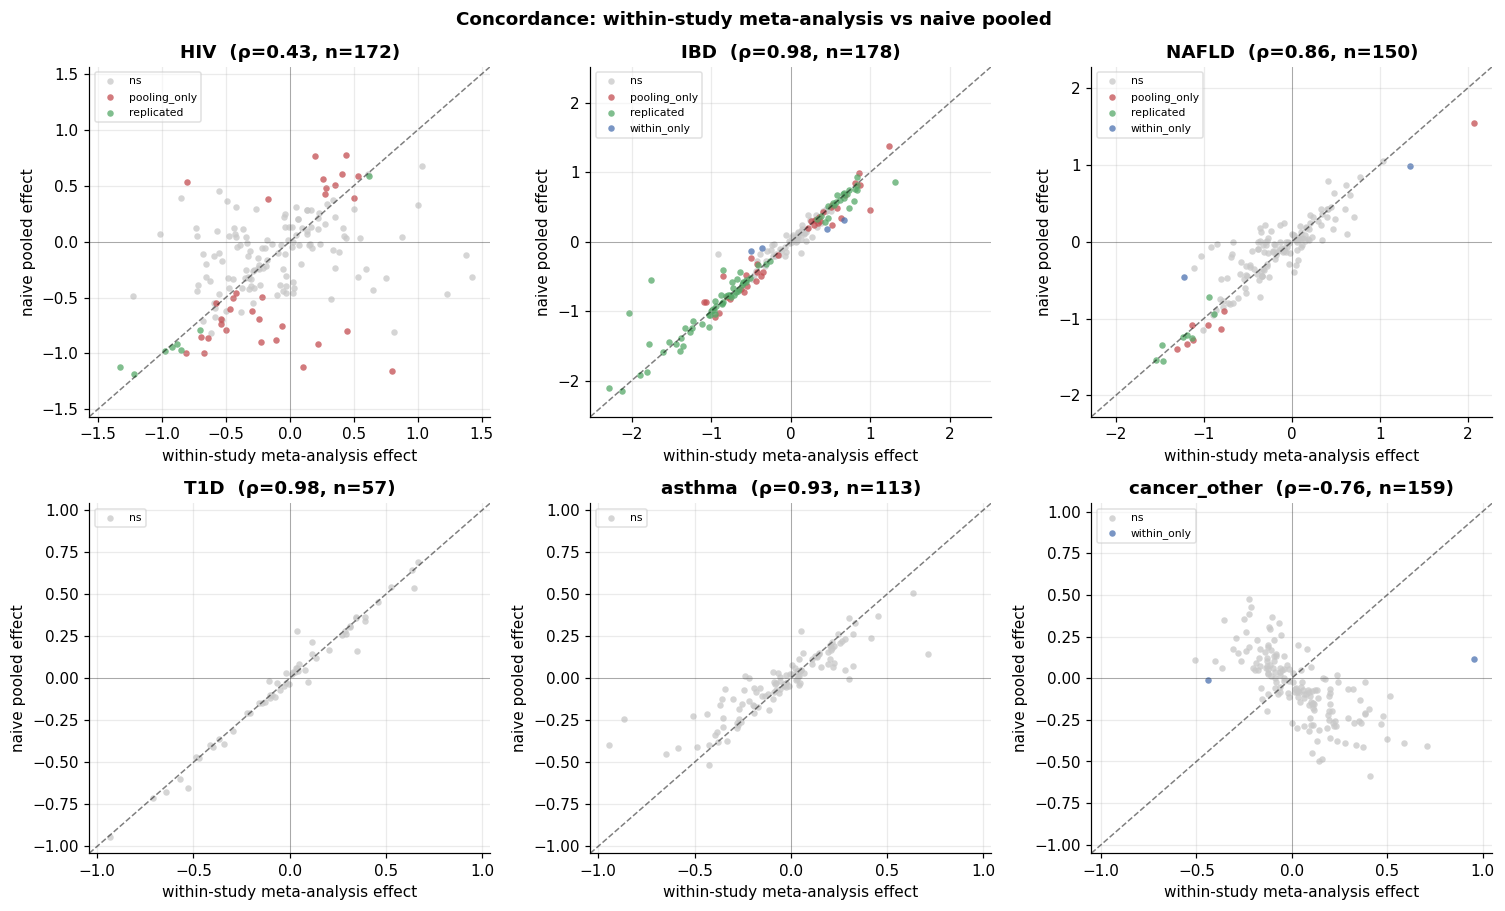

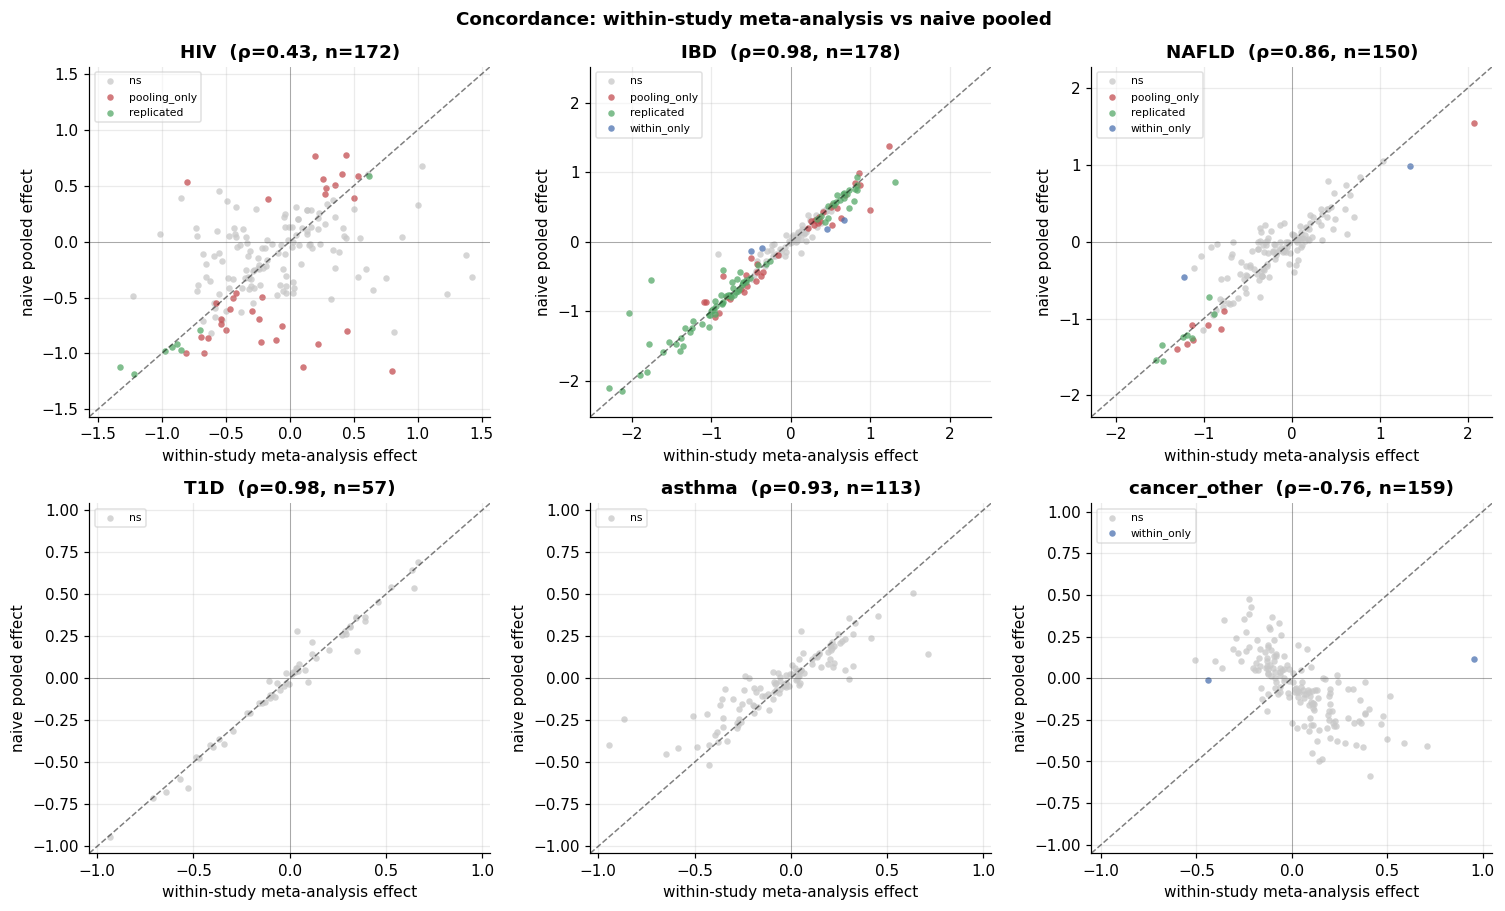

In [7]:
conc_per_taxon, conc_summ = [], []
for method in dcfg["pooled_methods"]:
    j, s = dfa.concordance(meta, pooled, pooled_method=method, fdr_alpha=dcfg["fdr_alpha"])
    conc_per_taxon.append(j)
    conc_summ.append(s)
concordance_taxa = pd.concat(conc_per_taxon, ignore_index=True)
concordance_summary = pd.concat(conc_summ, ignore_index=True)
concordance_taxa.to_csv(REPORTS / "concordance.csv", index=False)

print("Concordance summary (per category x pooled method):")
print(concordance_summary.round(3).to_string(index=False))

primary = concordance_taxa[concordance_taxa["pooled_method"] == "combat_ols"]
print(f"\nReplicated taxa (meta AND pooled combat_ols, q < {dcfg['fdr_alpha']}):")
rep = primary[primary["concordance_class"] == "replicated"].sort_values(["disease_category", "meta_q"])
print(rep[["disease_category", "genus", "meta_effect", "pooled_effect", "meta_q", "pooled_q"]]
      .round(3).to_string(index=False) if len(rep) else "  (none)")

print(f"\nPooling-only taxa (pooled combat_ols only — candidate batch artifacts):")
po = primary[primary["concordance_class"] == "pooling_only"]
print(po.groupby("disease_category").size().rename("n_pooling_only").to_string() if len(po) else "  (none)")

fig = dfa.plot_concordance(primary, fdr_alpha=dcfg["fdr_alpha"])
fig.savefig(FIGURES / "phase5_concordance.png"); plt.close(fig)
fig = dfa.plot_concordance(primary, fdr_alpha=dcfg["fdr_alpha"])
fig

## Step 5 — Batch-leakage quantification

A disease classifier (case vs control) — L2 logistic regression and gradient boosting — trained
under two CV schemes:

- **leave-project-out** — every held-out sample is from a project the model never saw
- **random k-fold** — held-out samples share projects with the training data

Per fold: a `StandardScaler` fit on the training rows only (for the linear model), then ROC AUC
and balanced accuracy on the held-out fold. **The gap between the two schemes is a direct
measurement of how much apparent predictive performance is study recognition rather than disease
signal** — the project-classifier result from the technical-variance step cashed out per disease.

batch-leakage: 98 fold-model scores (174s)

disease_category  model  leave_project_out  random_kfold  auc_gap
             HIV gboost              0.532         0.785    0.253
             HIV logreg              0.542         0.680    0.138
             IBD gboost              0.730         0.819    0.089
             IBD logreg              0.701         0.747    0.047
           NAFLD gboost              0.673         0.757    0.084
           NAFLD logreg              0.626         0.761    0.134
             T1D gboost              0.480         0.579    0.100
             T1D logreg              0.401         0.614    0.213
          asthma gboost              0.546         0.605    0.059
          asthma logreg              0.588         0.598    0.010
    cancer_other gboost              0.566         0.710    0.144
    cancer_other logreg              0.595         0.640    0.044


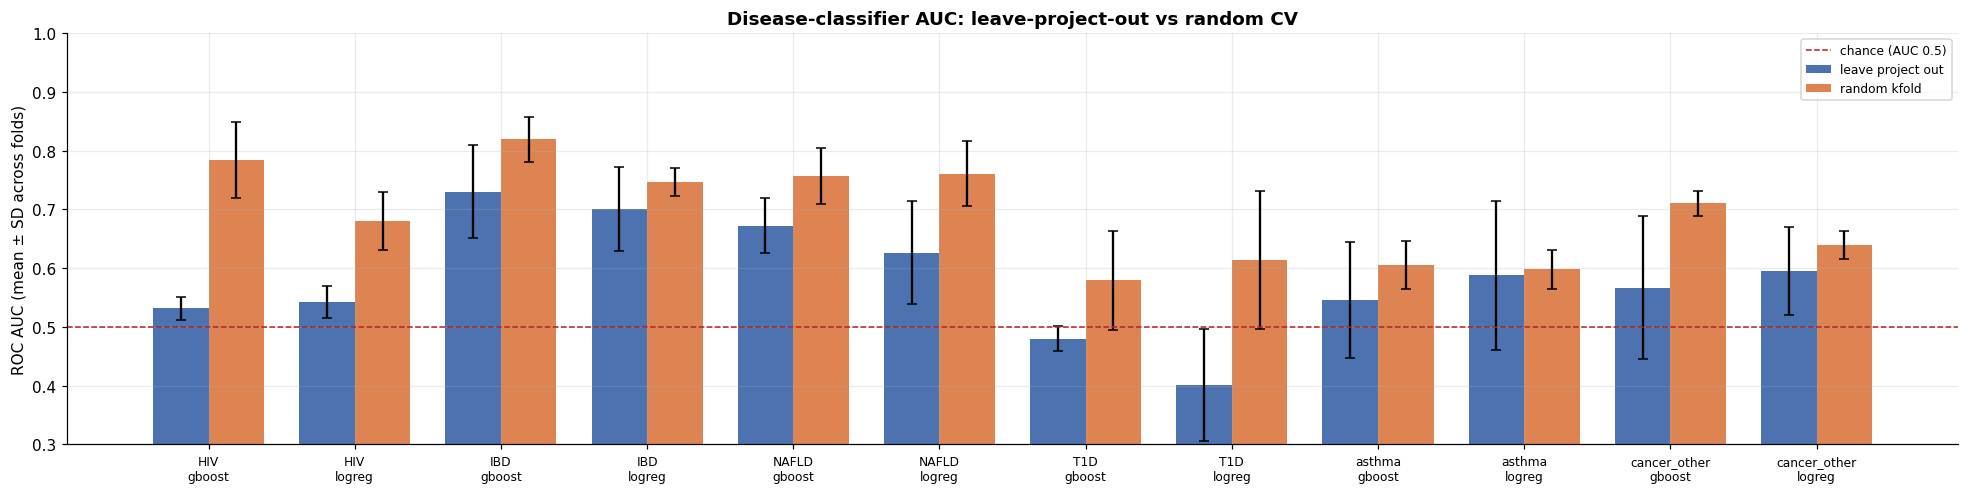

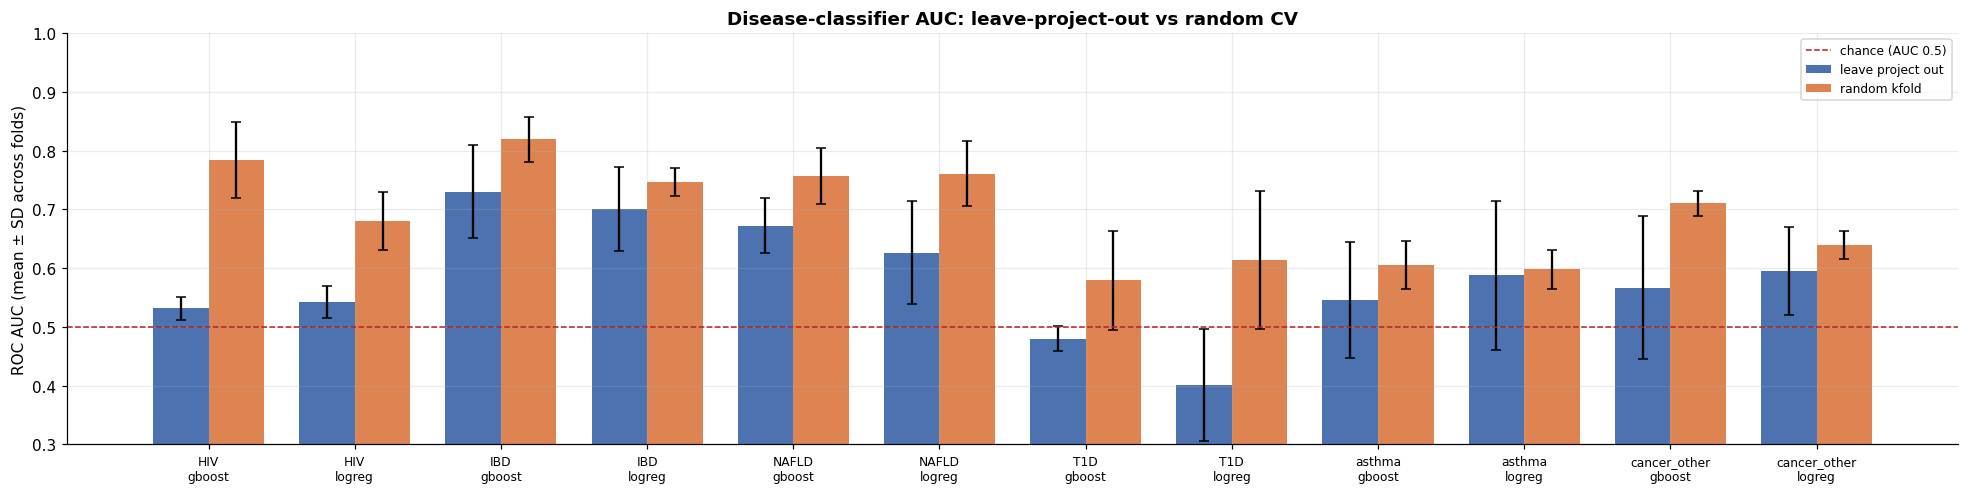

In [8]:
t0 = time.time()
leakage = pd.concat(
    [dfa.batch_leakage_cv(
        clr_df, frame, cat, SEED,
        n_splits=blcfg["cv_folds"], models=tuple(blcfg["models"]),
        logreg_C=blcfg["logreg_C"], gboost_max_iter=blcfg["gboost_max_iter"],
        gboost_learning_rate=blcfg["gboost_learning_rate"], gboost_max_depth=blcfg["gboost_max_depth"])
     for cat in CATS],
    ignore_index=True,
)
leakage.to_csv(REPORTS / "classifier_cv.csv", index=False)
leak_long, leak_wide = dfa.batch_leakage_summary(leakage)
print(f"batch-leakage: {len(leakage):,} fold-model scores ({time.time() - t0:.0f}s)\n")
print(leak_wide.round(3).to_string(index=False))

fig = dfa.plot_batch_leakage(leak_long)
fig.savefig(FIGURES / "phase5_batch_leakage.png"); plt.close(fig)
fig = dfa.plot_batch_leakage(leak_long)
fig

## Step 6 — Checks

- every result carries an effect size, a CI and an FDR-corrected q — no bare p-values
- taxon counts tested and the multiple-testing universe are recorded per analysis
- the batch-leakage step reports **both** CV schemes side by side

In [9]:
# no bare p-values: every results table has effect + q (+ CI where a pooled estimate exists)
for name, df in [("per_project", per_project), ("meta", meta), ("pooled", pooled)]:
    assert {"effect" if "effect" in df.columns else "pooled_effect", "q"}.issubset(df.columns), name
    assert "p" in df.columns, name
assert {"ci_low", "ci_high"}.issubset(meta.columns)
assert {"ci_low", "ci_high"}.issubset(pooled.columns)
print("PASS - every differential result carries effect size + q; meta/pooled carry a CI")

# multiple-testing universe is recorded per analysis
assert (per_project["n_taxa_tested"] > 0).all()
assert (meta["k_projects"] >= dcfg["meta_min_projects_per_taxon"]).all()
assert (pooled["n_taxa_tested"] > 0).all()
print(f"PASS - taxa-tested universe recorded per analysis "
      f"(within-project: {per_project['n_taxa_tested'].min()}-{per_project['n_taxa_tested'].max()} per project; "
      f"pooled: {pooled['n_taxa_tested'].min()}-{pooled['n_taxa_tested'].max()} per category)")

# the batch-leakage step reports both CV schemes for every (category, model)
schemes = set(leakage["cv_scheme"].unique())
assert {"leave_project_out", "random_kfold"}.issubset(schemes), schemes
pairs = leakage.groupby(["disease_category", "model"])["cv_scheme"].nunique()
assert (pairs == 2).all(), f"a (category, model) is missing a CV scheme:\n{pairs[pairs != 2]}"
print("PASS - batch-leakage step reports leave-project-out AND random k-fold for every (category, model)")

report_md = dfa.differential_report_md(
    elig, meta, concordance_summary[concordance_summary["pooled_method"] == "combat_ols"],
    leak_wide, fdr_alpha=dcfg["fdr_alpha"], pooled_method="combat_ols",
)
(REPORTS / "differential_report.md").write_text(report_md, encoding="utf-8")
print("\nwrote reports/differential_report.md")

PASS - every differential result carries effect size + q; meta/pooled carry a CI
PASS - taxa-tested universe recorded per analysis (within-project: 5-260 per project; pooled: 119-242 per category)
PASS - batch-leakage step reports leave-project-out AND random k-fold for every (category, model)

wrote reports/differential_report.md


## Summary

In [10]:
for f in (sorted(REPORTS.glob("differential_*")) + sorted(REPORTS.glob("concordance*"))
          + sorted(REPORTS.glob("classifier_cv*")) + sorted(FIGURES.glob("phase5_*"))):
    print(f"{str(f.relative_to(ROOT)):48s} {f.stat().st_size / 1e3:8.1f} KB")

reports\differential_meta.csv                       263.1 KB
reports\differential_per_project.csv                849.3 KB
reports\differential_pooled.csv                     601.8 KB
reports\differential_report.md                        9.1 KB
reports\concordance.csv                             527.6 KB
reports\classifier_cv.csv                             8.2 KB
reports\figures\phase5_batch_leakage.png             58.7 KB
reports\figures\phase5_concordance.png              211.6 KB
reports\figures\phase5_meta_volcano.png             162.2 KB


## Results and notes

### What this notebook produced

- `reports/differential_per_project.csv` — Step 1: one row per (disease category, project, taxon)
  with the OLS effect + SE + p + BH-q, the Wilcoxon p and rank-biserial, the covariates used, and
  the per-project taxon count (the multiple-testing universe).
- `reports/differential_meta.csv` — Step 2: DerSimonian-Laird pooled effect, 95% CI, I², tau²,
  project count and BH-q per (category, taxon).
- `reports/differential_pooled.csv` — Step 3: the same samples pooled and corrected for project by
  ComBat+OLS and by a project random-intercept mixed model.
- `reports/concordance.csv` — Step 4: meta vs each pooled method per taxon, with the replicated /
  pooling-only / within-only classification.
- `reports/classifier_cv.csv` — Step 5: per-fold AUC / balanced accuracy for both models under
  leave-project-out and random k-fold.
- `reports/differential_report.md` and `reports/figures/phase5_{meta_volcano,concordance,batch_leakage}.png`.

### How to read it

- **Step 4 is the headline.** A taxon that is *replicated* (significant in the within-study
  meta-analysis **and** the naive pooled test) is a confident finding. A *pooling-only* taxon —
  significant only once samples are pooled across labs — is exactly what the strong study signature
  predicts a naive analysis would manufacture, and should be treated as a likely batch artifact,
  not a discovery. A *within-only* taxon is plausibly real but under-powered.
- **Step 5 quantifies the temptation.** Where the random-k-fold AUC sits well above the
  leave-project-out AUC, a classifier evaluated the usual way is reading study identity, not
  disease. That gap, per disease, is the concrete version of the project-classifier result from
  the technical-variance step.

### Scope / caveats

- **Within-study cohort only.** Steps 1–3 run on `cohort_within_project` (41 projects). Reaching
  the full labelled catalogue (116 projects) needs the remaining candidate label fields curated
  into `config/within_study_review.csv` — flagged since harmonisation, not approximated here.
- **`cancer_other` is heterogeneous** — mostly colorectal adenoma/carcinoma studies plus one
  gastric-cancer study; read its pooled effects with that in mind.
- **Pure-Python differential abundance.** ANCOM-BC / ALDEx2 (`rpy2` + R) are not installed; Step 1
  uses the OLS-on-CLR contrast with a Wilcoxon cross-check.
- **ComBat with few batches.** Several categories have only 2–3 projects, so the ComBat
  location/scale estimates per batch are themselves noisy — part of why Step 4, not Step 3 alone,
  is the result.

### For the validation pass that follows

Re-run Steps 2 and 3 with `disease_label` permuted within project (the label-shuffling null) and
confirm no taxon survives FDR; sweep the depth threshold (5k / 10k / 20k) and the prevalence
filter (1% / 10%) and report how the *replicated* set moves. The `concordance.csv` classification
is the object those sensitivity checks act on.